In [5]:
from typing import TypedDict, Dict
from langgraph.graph import StateGraph

In [6]:
# Create an AgentState class - shared data structure that keeps the state of the agent

class AgentState(TypedDict): # Define the state schema
    message: str
    
# Create a node, input type of a node is the state of the agent, the output is also the state 
# Important to add doc strings as it allows LLM to understand what the node does
def greeting_node(state: AgentState) -> AgentState:
    """ Simple node that add a message to the state """
    state["message"] = f"Hello, {state['message']}!  How you doing?"
    return state



In [7]:
# Create StateGraph passing the state schema
graph = StateGraph(AgentState)

# Create node.  Pass the name of the node, and the function to be executed
graph.add_node("greeter", greeting_node)

# Set entry point
graph.set_entry_point("greeter")

# Set end point
graph.set_finish_point("greeter")

# Now compile
app = graph.compile()


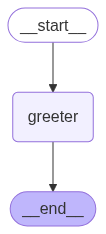

In [8]:
# Display graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
# Run the graph
result = app.invoke({"message": "John Wayne"})

# Display the result
result["message"]

'Hello, John Wayne!  How you doing?'

# Exercise 2

In [2]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph

In [4]:
# Create the state for the agent    
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str



In [5]:
def process_values(state: AgentState) -> AgentState:
    """ This function process handles multiple different inputs """
    state["result"] = f"Hi there {state['name']}, your sum = {sum(state['values'])}"

    return state

In [6]:
# Create graph
graph = StateGraph(AgentState)

# Now add a node
graph.add_node("process values", process_values)

# Set entry and finish points
graph.set_entry_point("process values")
graph.set_finish_point("process values")

# compile the graph
app = graph.compile()

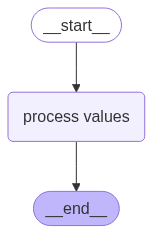

In [7]:
# Display graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
result = app.invoke({"values": [4,3, 2], "name": "John"})
result

{'values': [4, 3, 2], 'name': 'John', 'result': 'Hi there John, your sum = 9'}

# Additional exercise

In [11]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph

In [13]:
# Create the state for the agent    
class AgentState(TypedDict):
    values: List[int]
    name: str
    operation: str
    result: str


In [50]:
def process_ints(state: AgentState) -> AgentState:
    """ Apply the passed operation to each item of the int list and save the result """
    total = 0
    for idx, item in enumerate(state["values"]):
        if idx==0:
            total = item
        else:
            if state["operation"] == '+':
                total += item
            elif state["operation"] == '*':
                total *= item
            else:
                total = 0
                break

    state["result"] = f"Hi {state['name']}, your answer is {total}"
    return state

In [56]:
graph = StateGraph(AgentState) # Create graph
graph.add_node("process values", process_ints)
graph.set_entry_point("process values")
graph.set_finish_point("process values")

app=graph.compile()
result = app.invoke({"values": [1,2,3,4], "name": "Jack Sparrow", "operation": "*"})
result

{'values': [1, 2, 3, 4],
 'name': 'Jack Sparrow',
 'operation': '*',
 'result': 'Hi Jack Sparrow, your answer is 24'}